# Phase 5: Feature Extraction - LPDP Sentiment Analysis## TujuanMengekstrak features dari teks yang sudah dipreproses menggunakan 3 metode:1. **TF-IDF Vectorization (n-gram)** - Traditional feature extraction2. **Bag of Words (BoW) Baseline** - Simple baseline approach3. **IndoBERT Embeddings ([CLS] token)** - Deep learning contextual embeddings## Output- `feature_tfidf_ngram.pkl` - TF-IDF matrix dengan n-gram (1,2,3)- `feature_bow.pkl` - Bag of Words matrix- `feature_indobert_embeddings.pkl` - IndoBERT embeddings (768-dim)- `feature_extraction_summary.json` - Metadata dan statistik## Dataset- Input: `data/processed/dataset_lpdp_preprocessed.csv` (1.038 artikel dengan `text_clean`) utk TF-IDF dan BoW- Input: `data/processed/dataset_lpdp_preprocessed_bert.csv` (1.038 artikel dengan `text_bert`) utk IndoBERT- Target: Sentimen labels (Positive/Negative/Neutral)


## Setup: Import Libraries dan Load Dataset

In [2]:
! pip install scikit-learn

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import pickle
import json
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Traditional NLP: TF-IDF & BoW
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import normalize

# Deep Learning: IndoBERT
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm

# Visualization & Utilities
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("✅ All libraries imported successfully")
print(f"PyTorch device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

✅ All libraries imported successfully
PyTorch device: cpu


## Load dataset data/processed/dataset_lpdp_preprocessed.csv


In [2]:
# Set working directorywork_dir = Path.cwd()print(f"Working directory: {work_dir}")# Load preprocessed datasetdf = pd.read_csv('data/processed/dataset_lpdp_preprocessed.csv')print(f"\n📊 Dataset Loaded:")print(f"  - Total articles: {len(df)}")print(f"  - Columns: {df.columns.tolist()}")print(f"\n  Sentiment distribution:")print(df['Sentiment'].value_counts())# Check for missing values in text_cleanmissing_count = df['text_clean'].isna().sum()empty_count = (df['text_clean'].str.len() == 0).sum()print(f"\n  Missing values: {missing_count}")print(f"  Empty strings: {empty_count}")# Show sampleprint(f"\n📝 Sample text_clean (first article):")print(df['text_clean'].iloc[0][:200] + "...")


Working directory: c:\Users\Salwa\OneDrive\Dokumen\PBA\PBA_new\PBA-new\Project A

📊 Dataset Loaded:
  - Total articles: 1038
  - Columns: ['doc_id', 'Title', 'Release Date', 'URL', 'Publisher', 'PiC', 'Valid?', 'Sentiment', 'Notes', 'Actual_URL', 'Content', 'label_4', 'label_name', 'text_clean']

  Sentiment distribution:
Sentiment
Positive    385
Neutral     342
Negative    311
Name: count, dtype: int64

  Missing values: 0
  Empty strings: 0

📝 Sample text_clean (first article):
cegah kolusi nepotisme program lpdp nilai ketat seleksi jakarta sekretaris komisi e dprd dki jakarta justin adrian untayana nilai seleksi terima program beasiswa lembaga kelola dana didik lpdp versi j...


## Method 1: TF-IDF Vectorization (n-gram)

TF-IDF (Term Frequency-Inverse Document Frequency) adalah metode klasik untuk mengekstrak features dari teks.

**Konfigurasi:**
- **n-gram:** (1,2,3) - unigram, bigram, trigram
- **min_df:** 2 - minimum document frequency (hapus term yang muncul di < 2 dokumen)
- **max_df:** 0.95 - maximum document frequency (hapus term yang muncul di > 95% dokumen)
- **max_features:** 5000 - ambil top 5000 features terbaik

**Output:** Sparse matrix (1.038 x 5000)

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Pastikan kolom teks tidak ada NaN
texts = df['text_clean'].fillna('').astype(str)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),          # unigram, bigram, trigram
    min_df=2,                    # minimal muncul di 2 dokumen
    max_df=0.95,                 # buang term yang terlalu umum
    max_features=5000,           # batasi 5000 fitur
    strip_accents='unicode',
    lowercase=True,
    analyzer='word',
    token_pattern=r'\w{2,}',     # minimal 2 karakter, lebih bersih dari \w{1,}
    sublinear_tf=True
)

# Fit and transform
X_tfidf = tfidf_vectorizer.fit_transform(texts)

# Feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

# Matrix stats
n_docs, n_features = X_tfidf.shape
total_elements = n_docs * n_features
non_zero = X_tfidf.nnz
density = non_zero / total_elements
sparsity = 1 - density

# TF-IDF value stats
tfidf_min = X_tfidf.data.min() if non_zero > 0 else 0
tfidf_max = X_tfidf.data.max() if non_zero > 0 else 0
tfidf_mean = X_tfidf.data.mean() if non_zero > 0 else 0

print("✅ TF-IDF extraction complete\n")
print(f"📊 TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"  - Documents: {n_docs}")
print(f"  - Features: {n_features}")
print(f"  - Non-zero values: {non_zero}")
print(f"  - Density: {density:.2%}")
print(f"  - Sparsity: {sparsity:.2%}")

print("\n  Sample features (first 20):")
print(feature_names[:20])

print("\n  TF-IDF value statistics:")
print(f"  - Min: {tfidf_min:.4f}")
print(f"  - Max: {tfidf_max:.4f}")
print(f"  - Mean: {tfidf_mean:.4f}")


✅ TF-IDF extraction complete

📊 TF-IDF Matrix Shape: (1038, 5000)
  - Documents: 1038
  - Features: 5000
  - Non-zero values: 218277
  - Density: 4.21%
  - Sparsity: 95.79%

  Sample features (first 20):
['aas' 'abadi' 'abadi bidang' 'abadi bidang didik' 'abadi budaya'
 'abadi didik' 'abadi didik kelola' 'abadi guru' 'abadi kelola'
 'abadi kelola lpdp' 'abadi lpdp' 'abadi teliti' 'abdi' 'abdi alumni'
 'abdi indonesia' 'abdi indonesia kali' 'abdi indonesia selesai'
 'abdi kali' 'abdi kontribusi' 'abdi kontribusi indonesia']

  TF-IDF value statistics:
  - Min: 0.0068
  - Max: 0.5916
  - Mean: 0.0610



Top 20 TF-IDF Features (by average score):
   1. beasiswa             - 0.0433
   2. terima               - 0.0323
   3. indonesia            - 0.0306
   4. didik                - 0.0301
   5. beasiswa lpdp        - 0.0289
   6. dana                 - 0.0288
   7. program              - 0.0275
   8. terima beasiswa      - 0.0266
   9. negara               - 0.0262
  10. daftar               - 0.0259
  11. studi                - 0.0258
  12. negeri               - 0.0244
  13. anak                 - 0.0234
  14. alumni               - 0.0217
  15. seleksi              - 0.0208
  16. kelola               - 0.0204
  17. orang                - 0.0203
  18. kontribusi           - 0.0202
  19. milik                - 0.0200
  20. wajib                - 0.0198


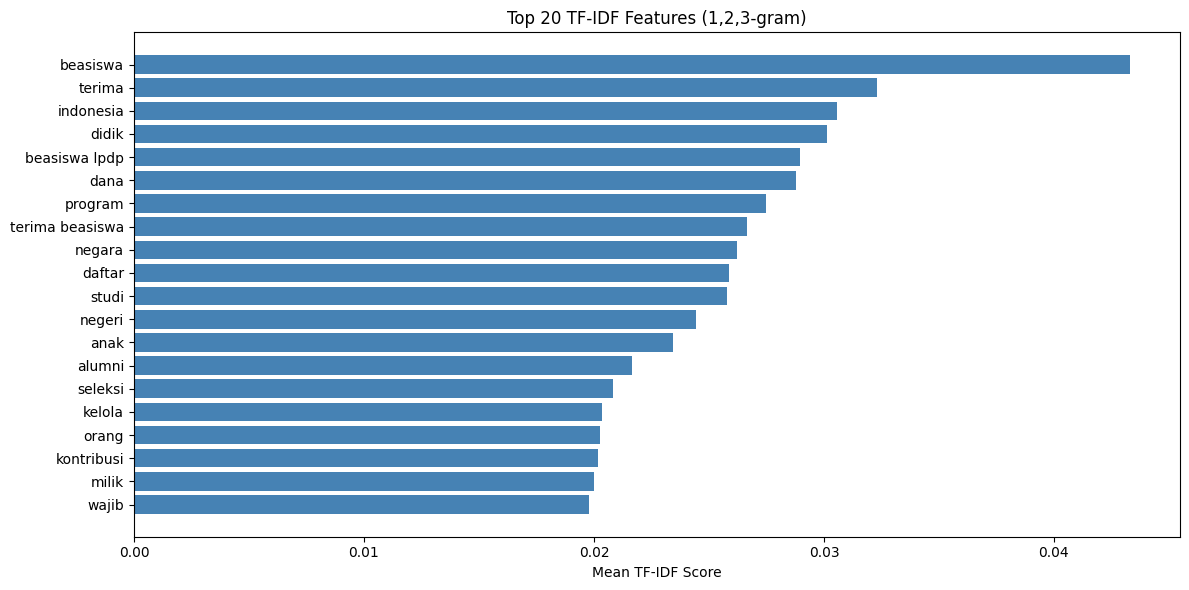

In [4]:
# Visualize top TF-IDF features
tfidf_data = tfidf_matrix if 'tfidf_matrix' in globals() else X_tfidf
tfidf_features = feature_names_tfidf if 'feature_names_tfidf' in globals() else feature_names

# Calculate mean TF-IDF score per feature
mean_tfidf = np.asarray(tfidf_data.mean(axis=0)).ravel()

# Ambil top 20 fitur
top_indices = mean_tfidf.argsort()[-20:][::-1]
top_features = np.asarray(tfidf_features)[top_indices]
top_scores = mean_tfidf[top_indices]

print("\nTop 20 TF-IDF Features (by average score):")
for i, (feature, score) in enumerate(zip(top_features, top_scores), 1):
    print(f"  {i:2d}. {feature:20s} - {score:.4f}")

# Plot
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_features)), top_scores, color='steelblue')
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Mean TF-IDF Score')
plt.title('Top 20 TF-IDF Features (1,2,3-gram)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


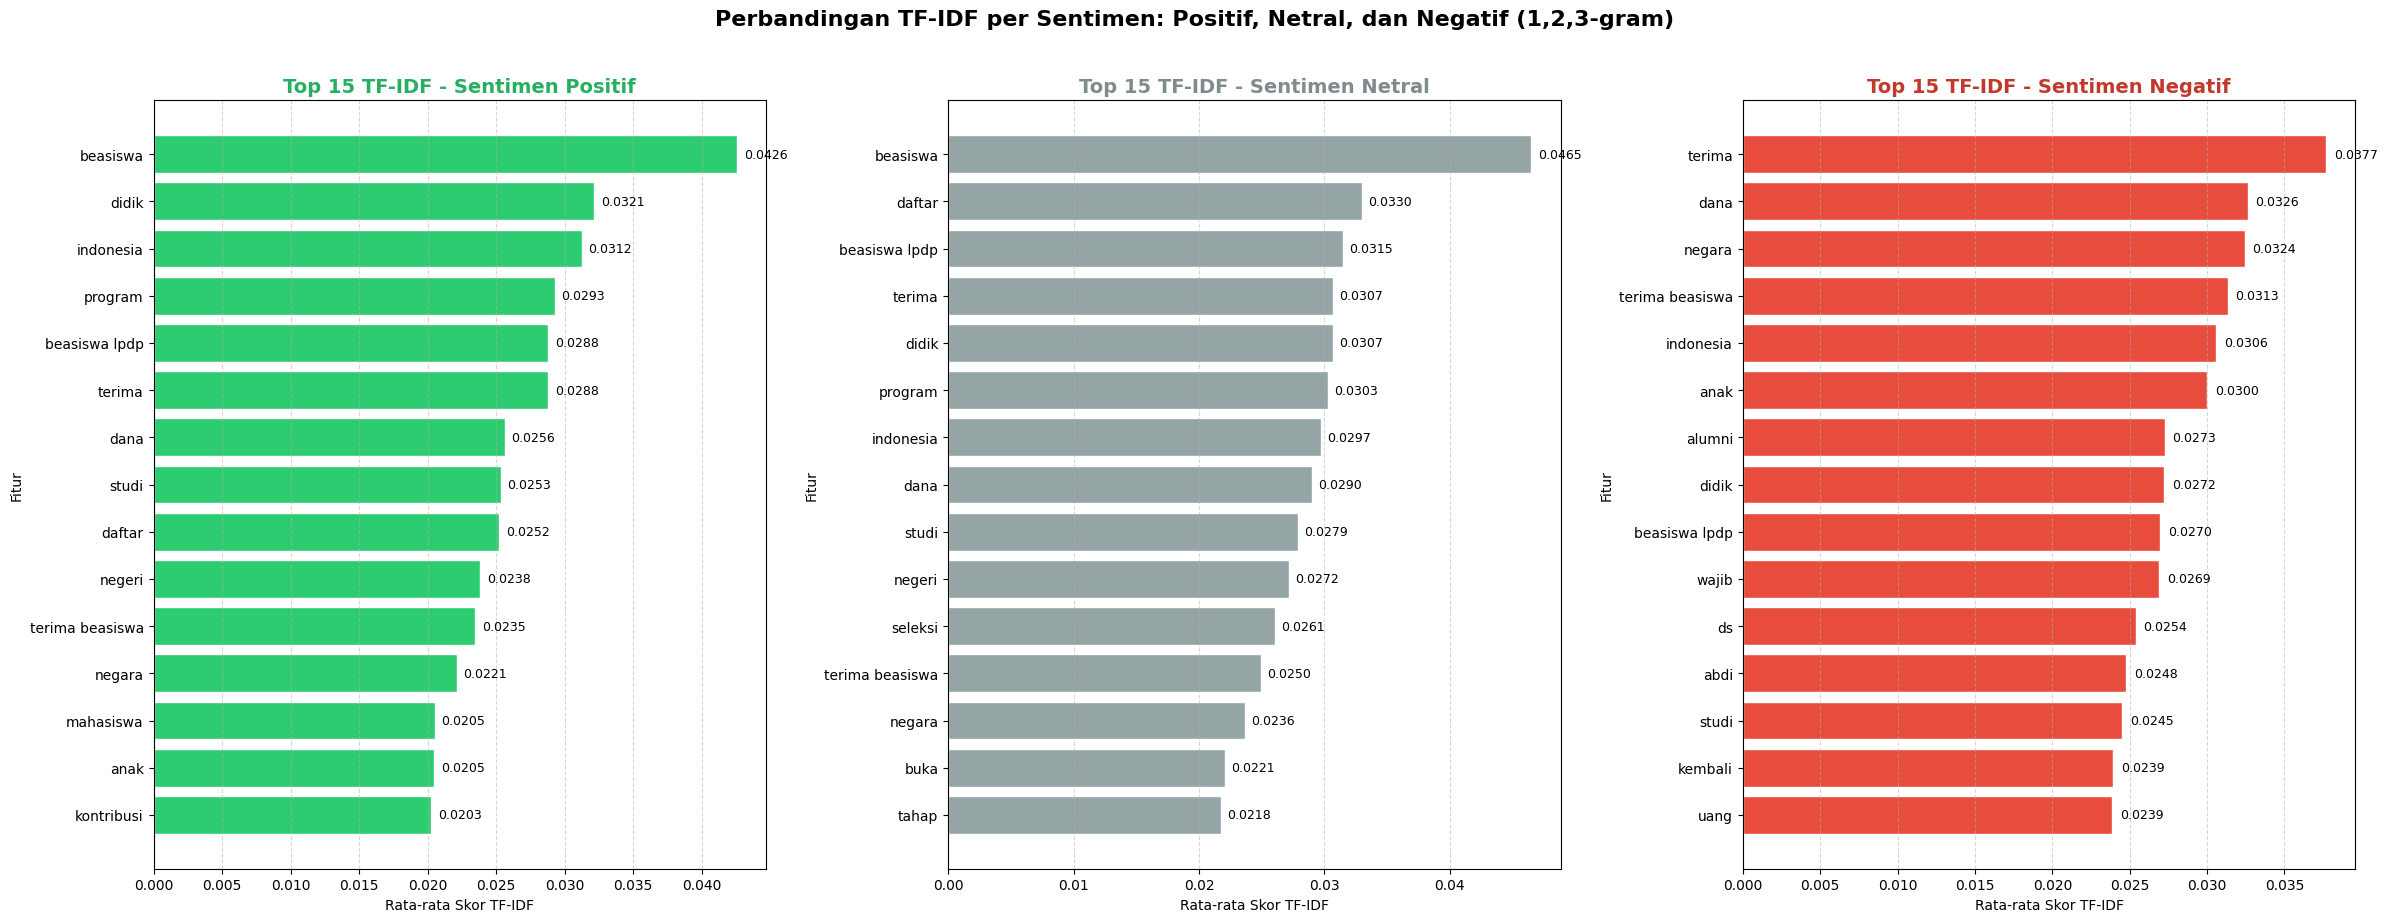


Top 15 TF-IDF - Sentimen Positive


,Fitur,Skor_TFIDF
436,beasiswa,0.042558
1027,didik,0.032149
1647,indonesia,0.031246
3566,program,0.029261
488,beasiswa lpdp,0.028810
4584,terima,0.028787
909,dana,0.025620
4299,studi,0.025329
854,daftar,0.025222
3108,negeri,0.023843



Top 15 TF-IDF - Sentimen Neutral


,Fitur,Skor_TFIDF
399,beasiswa,0.046512
849,daftar,0.032997
459,beasiswa lpdp,0.031465
4519,terima,0.030710
1070,didik,0.030675
3438,program,0.030266
1661,indonesia,0.029727
964,dana,0.028978
4130,studi,0.027880
3011,negeri,0.027193



Top 15 TF-IDF - Sentimen Negative


,Fitur,Skor_TFIDF
4458,terima,0.037693
867,dana,0.032620
2875,negara,0.032424
4462,terima beasiswa,0.031325
1510,indonesia,0.030590
218,anak,0.029990
153,alumni,0.027264
974,didik,0.027249
552,beasiswa lpdp,0.026974
4848,wajib,0.026917


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Konfigurasi sentimen dan warna
sentiment_config = {
    'Positive': {
        'title': 'Sentimen Positif',
        'color': '#2ecc71',
        'title_color': '#27ae60'
    },
    'Neutral': {
        'title': 'Sentimen Netral',
        'color': '#95a5a6',
        'title_color': '#7f8c8d'
    },
    'Negative': {
        'title': 'Sentimen Negatif',
        'color': '#e74c3c',
        'title_color': '#c0392b'
    }
}

tfidf_results = {}

# Hitung TF-IDF per sentimen
for sentiment, config in sentiment_config.items():
    texts = df[df['Sentiment'] == sentiment]['text_clean'].fillna('').astype(str)

    tfidf_vectorizer = TfidfVectorizer(
        ngram_range=(1, 3),      # unigram, bigram, trigram
        min_df=2,
        max_df=0.95,
        max_features=5000,
        lowercase=True,
        token_pattern=r'\w{2,}',
        sublinear_tf=True
    )

    tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
    feature_names = tfidf_vectorizer.get_feature_names_out()

    mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

    df_tfidf = pd.DataFrame({
        'Fitur': feature_names,
        'Skor_TFIDF': mean_tfidf
    }).sort_values(by='Skor_TFIDF', ascending=False)

    tfidf_results[sentiment] = df_tfidf

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(24, 9))

for ax, (sentiment, config) in zip(axes, sentiment_config.items()):
    top15 = tfidf_results[sentiment].head(15)

    ax.barh(
        top15['Fitur'][::-1],
        top15['Skor_TFIDF'][::-1],
        color=config['color'],
        edgecolor='white'
    )

    ax.set_title(
        f"Top 15 TF-IDF - {config['title']}",
        fontsize=14,
        fontweight='bold',
        color=config['title_color']
    )
    ax.set_xlabel('Rata-rata Skor TF-IDF')
    ax.set_ylabel('Fitur')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

    for i, (fitur, skor) in enumerate(zip(top15['Fitur'][::-1], top15['Skor_TFIDF'][::-1])):
        ax.text(skor + 0.0005, i, f'{skor:.4f}', va='center', fontsize=9)

plt.suptitle(
    'Perbandingan TF-IDF per Sentimen: Positif, Netral, dan Negatif (1,2,3-gram)',
    fontsize=16,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()

# Tampilkan tabel top 15 tiap sentimen
for sentiment, df_result in tfidf_results.items():
    print(f"\nTop 15 TF-IDF - Sentimen {sentiment}")
    display(df_result.head(15))

## Method 2: Bag of Words (BoW) Baseline

Bag of Words adalah metode paling sederhana - hanya menghitung term frequency tanpa normalisasi TF-IDF.

**Konfigurasi:**
- **Analyzer:** word-level
- **min_df:** 2 - minimum document frequency
- **max_df:** 0.95 - maximum document frequency
- **max_features:** 5000 - top 5000 features

**Output:** Sparse matrix dengan word counts (1.038 x 5000)

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

texts = df['text_clean'].fillna('').astype(str)

bow_vectorizer = CountVectorizer(
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    max_features=5000,
    lowercase=True,
    token_pattern=r'\w{2,}'
)

X_bow = bow_vectorizer.fit_transform(texts)
feature_names_bow = bow_vectorizer.get_feature_names_out()

n_docs, n_features = X_bow.shape
total_elements = n_docs * n_features
non_zero = X_bow.nnz
density = non_zero / total_elements
sparsity = 1 - density

bow_min = X_bow.data.min() if non_zero > 0 else 0
bow_max = X_bow.data.max() if non_zero > 0 else 0
bow_mean = X_bow.data.mean() if non_zero > 0 else 0
bow_median = np.median(X_bow.data) if non_zero > 0 else 0

print("✅ Bag of Words extraction complete\n")
print(f"📊 BoW Matrix Shape: {X_bow.shape}")
print(f"  - Documents: {n_docs}")
print(f"  - Features: {n_features}")
print(f"  - Non-zero values: {non_zero}")
print(f"  - Density: {density:.2%}")
print(f"  - Sparsity: {sparsity:.2%}")

print("\n  Sample features (first 20):")
print(feature_names_bow[:20])

print("\n  Term frequency statistics:")
print(f"  - Min: {bow_min}")
print(f"  - Max: {bow_max}")
print(f"  - Mean: {bow_mean:.2f}")
print(f"  - Median: {bow_median:.2f}")

✅ Bag of Words extraction complete

📊 BoW Matrix Shape: (1038, 5000)
  - Documents: 1038
  - Features: 5000
  - Non-zero values: 218277
  - Density: 4.21%
  - Sparsity: 95.79%

  Sample features (first 20):
['aas' 'abadi' 'abadi bidang' 'abadi bidang didik' 'abadi budaya'
 'abadi didik' 'abadi didik kelola' 'abadi guru' 'abadi kelola'
 'abadi kelola lpdp' 'abadi lpdp' 'abadi teliti' 'abdi' 'abdi alumni'
 'abdi indonesia' 'abdi indonesia kali' 'abdi indonesia selesai'
 'abdi kali' 'abdi kontribusi' 'abdi kontribusi indonesia']

  Term frequency statistics:
  - Min: 1
  - Max: 64
  - Mean: 1.63
  - Median: 1.00



Top 20 Terms (by total frequency):
   1. beasiswa             -   7945 occurrences
   2. dana                 -   3584 occurrences
   3. terima               -   3548 occurrences
   4. didik                -   3415 occurrences
   5. indonesia            -   3254 occurrences
   6. daftar               -   3032 occurrences
   7. beasiswa lpdp        -   2876 occurrences
   8. program              -   2765 occurrences
   9. studi                -   2288 occurrences
  10. negara               -   2250 occurrences
  11. terima beasiswa      -   2199 occurrences
  12. negeri               -   1867 occurrences
  13. anak                 -   1736 occurrences
  14. seleksi              -   1610 occurrences
  15. alumni               -   1376 occurrences
  16. kelola               -   1369 occurrences
  17. wajib                -   1334 occurrences
  18. milik                -   1324 occurrences
  19. biaya                -   1253 occurrences
  20. orang                -   1224 occurrences


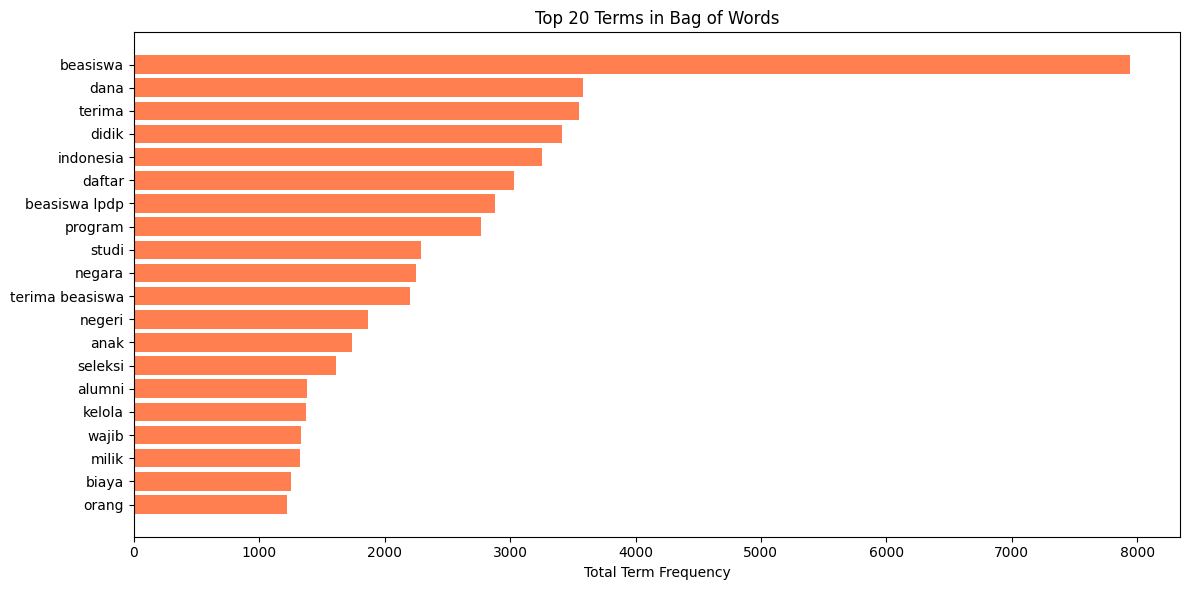

In [7]:
# Visualize top BoW features
bow_data = bow_matrix if 'bow_matrix' in globals() else X_bow
bow_features = feature_names_bow

# Calculate total term frequency per feature
total_counts = np.asarray(bow_data.sum(axis=0)).ravel()

# Ambil top 20 fitur
top_indices_bow = total_counts.argsort()[-20:][::-1]
top_features_bow = np.asarray(bow_features)[top_indices_bow]
top_counts = total_counts[top_indices_bow]

print("\nTop 20 Terms (by total frequency):")
for i, (feature, count) in enumerate(zip(top_features_bow, top_counts), 1):
    print(f"  {i:2d}. {feature:20s} - {int(count):6d} occurrences")

# Plot
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_features_bow)), top_counts, color='coral')
plt.yticks(range(len(top_features_bow)), top_features_bow)
plt.xlabel('Total Term Frequency')
plt.title('Top 20 Terms in Bag of Words')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

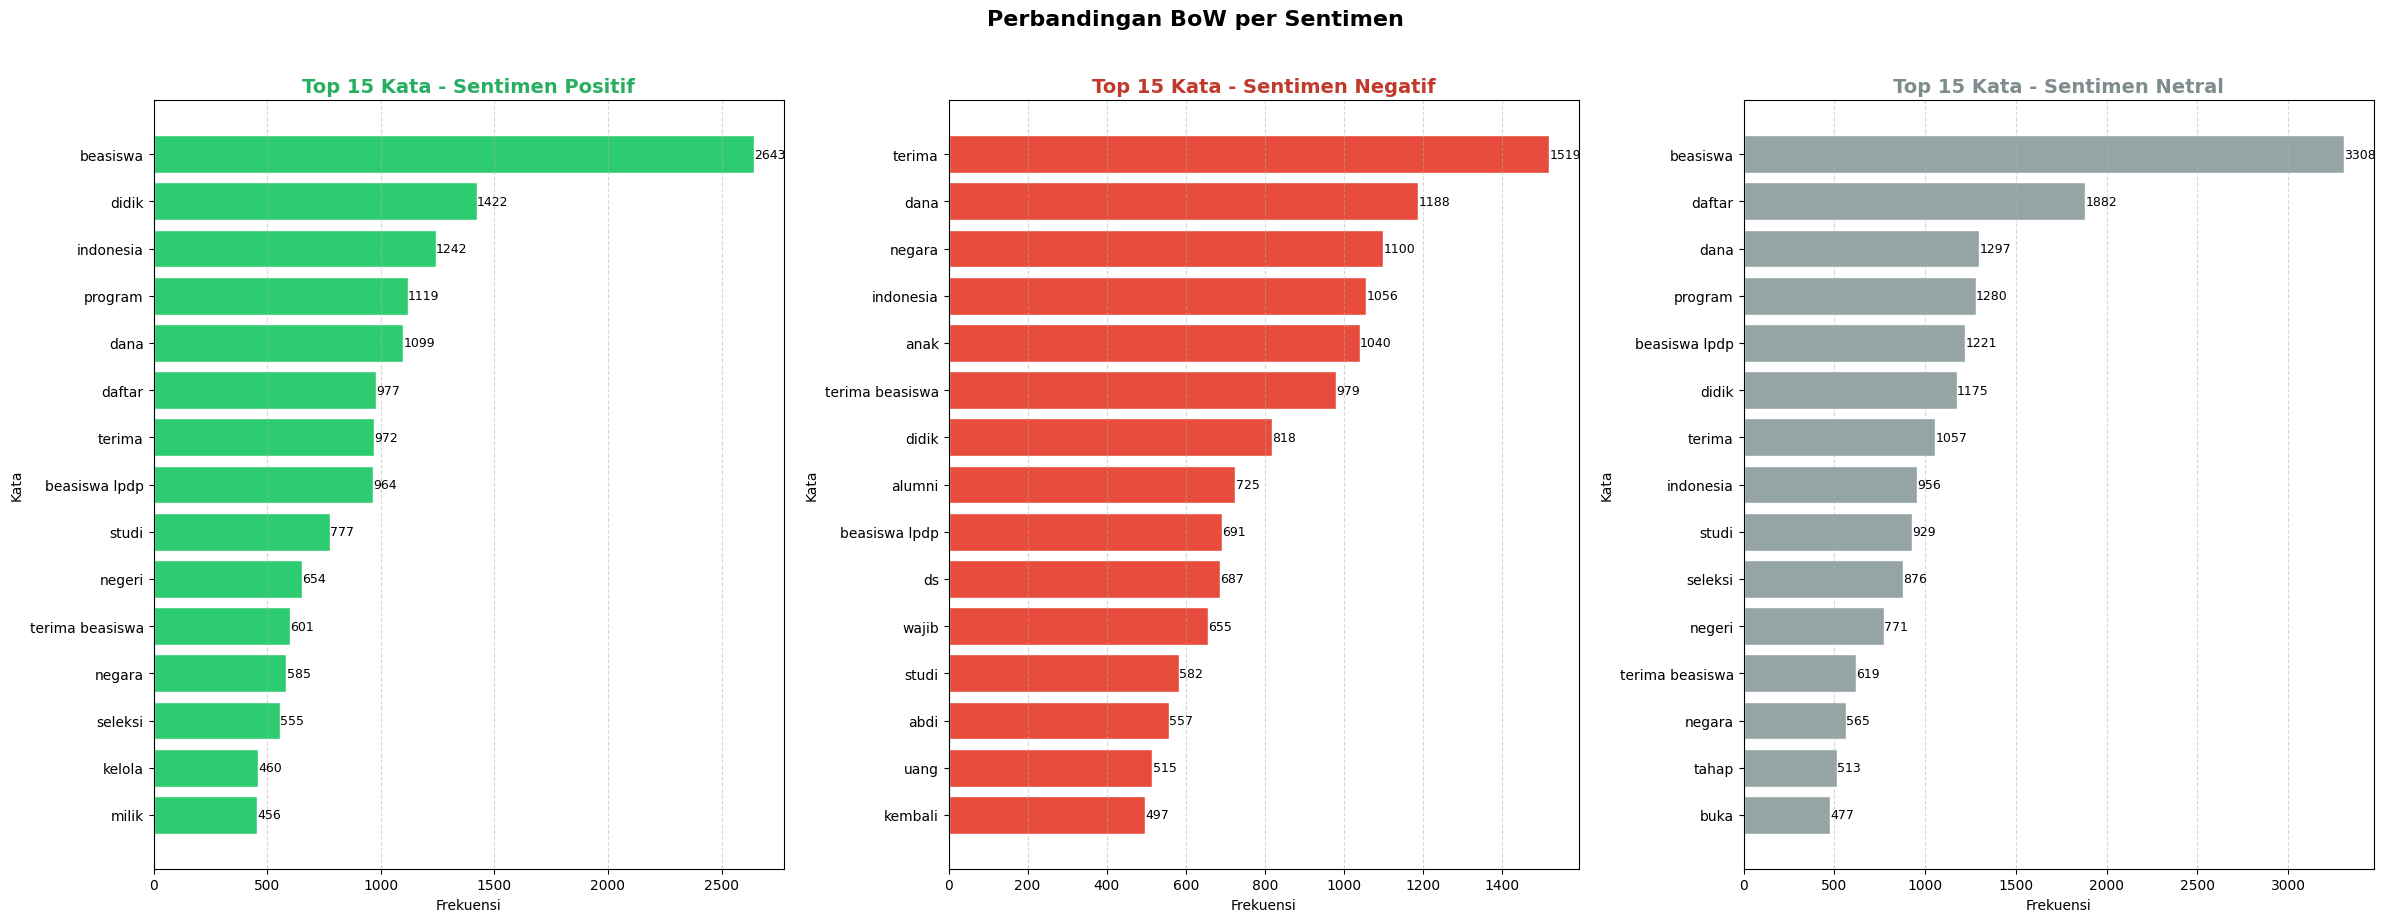

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

def get_top_words_by_sentiment(df, sentiment_label, top_n=15):
    texts = df[df['Sentiment'] == sentiment_label]['text_clean'].fillna('').astype(str)
    
    vectorizer = CountVectorizer(
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.95,
        token_pattern=r'\w{2,}'
    )
    
    X = vectorizer.fit_transform(texts)
    features = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1
    
    result = pd.DataFrame({
        'Kata': features,
        'Frekuensi': counts
    }).sort_values(by='Frekuensi', ascending=False).head(top_n)
    
    return result

df_bow_pos = get_top_words_by_sentiment(df, 'Positive', top_n=15)
df_bow_neg = get_top_words_by_sentiment(df, 'Negative', top_n=15)
df_bow_neu = get_top_words_by_sentiment(df, 'Neutral', top_n=15)

fig, axes = plt.subplots(1, 3, figsize=(24, 9))

plot_configs = [
    (df_bow_pos, 'Sentimen Positif', '#2ecc71', '#27ae60'),
    (df_bow_neg, 'Sentimen Negatif', '#e74c3c', '#c0392b'),
    (df_bow_neu, 'Sentimen Netral', '#95a5a6', '#7f8c8d')
]

for ax, (df_plot, title, bar_color, title_color) in zip(axes, plot_configs):
    ax.barh(
        df_plot['Kata'][::-1],
        df_plot['Frekuensi'][::-1],
        color=bar_color,
        edgecolor='white'
    )
    ax.set_title(f'Top 15 Kata - {title}', fontsize=14, fontweight='bold', color=title_color)
    ax.set_xlabel('Frekuensi')
    ax.set_ylabel('Kata')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

    for i, (kata, freq) in enumerate(zip(df_plot['Kata'][::-1], df_plot['Frekuensi'][::-1])):
        ax.text(freq + 1, i, str(int(freq)), va='center', fontsize=9)

plt.suptitle('Perbandingan BoW per Sentimen', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Method 3: IndoBERT Embeddings ([CLS] Token)IndoBERT adalah model transformer multilingual yang dilatih khusus untuk bahasa Indonesia.Kami menggunakan **[CLS] token** dari output layer terakhir sebagai representasi dense dari keseluruhan dokumen.**Model:** `indolem/indobert-base-uncased` (12 layers, 768 hidden dimension)**Process:**1. Gunakan dataset data/processed/dataset_lpdp_preprocessed_bert.csv 2. Tokenize setiap teks dengan IndoBERT tokenizer3. Jalankan forward pass melalui model4. Ekstrak [CLS] token embedding (768-dim)5. Lakukan normalisasi L2**Output:** Dense matrix (1.038 x 768)


## Load data/processed/dataset_lpdp_preprocessed_bert.csv


In [12]:
# Set working directorywork_dir = Path.cwd()print(f"Working directory: {work_dir}")# Load preprocessed datasetdf_bert = pd.read_csv('data/processed/dataset_lpdp_preprocessed_bert.csv')print(f"\n📊 Dataset Loaded:")print(f"  - Total articles: {len(df_bert)}")print(f"  - Columns: {df_bert.columns.tolist()}")print(f"\n  Sentiment distribution:")print(df_bert['Sentiment'].value_counts())# Check for missing values in text_cleanmissing_count = df_bert['text_bert'].isna().sum()empty_count = (df_bert['text_bert'].str.len() == 0).sum()print(f"\n  Missing values: {missing_count}")print(f"  Empty strings: {empty_count}")# Show sampleprint(f"\n📝 Sample text_clean (first article):")print(df['text_clean'].iloc[0][:200] + "...")


Working directory: c:\Users\Salwa\OneDrive\Dokumen\PBA\PBA_new\PBA-new\Project A

📊 Dataset Loaded:
  - Total articles: 1038
  - Columns: ['doc_id', 'Title', 'Release Date', 'URL', 'Publisher', 'PiC', 'Valid?', 'Sentiment', 'Notes', 'Actual_URL', 'Content', 'label_4', 'label_name', 'token_count', 'text_bert']

  Sentiment distribution:
Sentiment
Positive    385
Neutral     342
Negative    311
Name: count, dtype: int64

  Missing values: 0
  Empty strings: 0

📝 Sample text_clean (first article):
cegah kolusi nepotisme program lpdp nilai ketat seleksi jakarta sekretaris komisi e dprd dki jakarta justin adrian untayana nilai seleksi terima program beasiswa lembaga kelola dana didik lpdp versi j...


In [13]:
! pip install hf_xet

In [14]:
print("🔄 Setting up IndoBERT Model...")
print("="*60)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Model and tokenizer
model_name = "indolem/indobert-base-uncased"
print(f"Loading model: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model = model.to(device)
model.eval()  # Set to evaluation mode

print(f"✅ Model loaded successfully")
print(f"  - Model type: {type(model).__name__}")
print(f"  - Hidden size: {model.config.hidden_size}")
print(f"  - Num layers: {model.config.num_hidden_layers}")
print(f"  - Vocab size: {model.config.vocab_size}")

🔄 Setting up IndoBERT Model...
Using device: cpu
Loading model: indolem/indobert-base-uncased
✅ Model loaded successfully
  - Model type: BertModel
  - Hidden size: 768
  - Num layers: 12
  - Vocab size: 31923


In [15]:
print("\n🔄 Extracting IndoBERT Embeddings...")
print("="*60)

# Parameters
batch_size = 32
max_length = 512
embeddings_list = []

# Pastikan kolom text_bert aman
df_bert['text_bert'] = df_bert['text_bert'].fillna('').astype(str)

# Cek jika ada teks kosong
empty_count = df_bert['text_bert'].str.strip().eq('').sum()
if empty_count > 0:
    raise ValueError(f"Ada {empty_count} baris text_bert yang kosong. Periksa dataset BERT dulu.")

# Process in batches
total_batches = (len(df_bert) + batch_size - 1) // batch_size

with torch.no_grad():
    for batch_num in tqdm(range(total_batches), desc="Processing batches"):
        # Get batch texts
        start_idx = batch_num * batch_size
        end_idx = min((batch_num + 1) * batch_size, len(df_bert))
        batch_texts = df_bert['text_bert'].iloc[start_idx:end_idx].tolist()

        # Tokenize
        encoded = tokenizer(
            batch_texts,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Move to device
        input_ids = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        # Extract [CLS] token
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings_list.append(cls_embeddings)

# Concatenate all batches
indobert_embeddings = np.vstack(embeddings_list)

print("✅ IndoBERT extraction complete")
print(f"\n📊 Embeddings Shape: {indobert_embeddings.shape}")
print(f"  - Documents: {indobert_embeddings.shape[0]}")
print(f"  - Dimensions: {indobert_embeddings.shape[1]}")
print(f"  - Data type: {indobert_embeddings.dtype}")


🔄 Extracting IndoBERT Embeddings...


Processing batches: 100%|██████████| 33/33 [21:50<00:00, 39.70s/it] 


✅ IndoBERT extraction complete

📊 Embeddings Shape: (1038, 768)
  - Documents: 1038
  - Dimensions: 768
  - Data type: float32


Artinya ada matrix berukuran 1038 baris dan 768 kolom.
1038 = jumlah dokumen
768 = jumlah fitur/angka untuk mewakili setiap dokumen

In [23]:
# Normalize IndoBERT embeddings (L2 normalization)
print("\n🔧 Normalizing IndoBERT embeddings (L2 norm)...")
print("="*60)

# Cek shape sebelum normalisasi
print(f"Embedding shape sebelum normalisasi: {indobert_embeddings.shape}")

# Statistik sebelum normalisasi
print("\n- Before normalization:")
print(f"  Min : {indobert_embeddings.min():.4f}")
print(f"  Max : {indobert_embeddings.max():.4f}")
print(f"  Mean: {indobert_embeddings.mean():.4f}")
print(f"  Std : {indobert_embeddings.std():.4f}")

# L2 normalization
indobert_embeddings_normalized = normalize(indobert_embeddings, norm='l2')

# Statistik setelah normalisasi
print("\n- After L2 normalization:")
print(f"  Min : {indobert_embeddings_normalized.min():.4f}")
print(f"  Max : {indobert_embeddings_normalized.max():.4f}")
print(f"  Mean: {indobert_embeddings_normalized.mean():.4f}")
print(f"  Std : {indobert_embeddings_normalized.std():.4f}")

# Verify L2 norm
norms = np.linalg.norm(indobert_embeddings_normalized, axis=1)
print("\n- L2 norms:")
print(f"  Min : {norms.min():.4f}")
print(f"  Max : {norms.max():.4f}")
print(f"  Mean: {norms.mean():.4f}")

# Pastikan semua vektor berhasil dinormalisasi
assert np.allclose(norms, 1.0, atol=1e-5), "Ada embedding yang L2 norm-nya bukan 1.0"

# Gunakan embedding hasil normalisasi untuk tahap berikutnya
indobert_embeddings = indobert_embeddings_normalized

print("\n✅ IndoBERT embeddings berhasil dinormalisasi dan siap digunakan.")



🔧 Normalizing IndoBERT embeddings (L2 norm)...
Embedding shape sebelum normalisasi: (1038, 768)

- Before normalization:
  Min : -12.9511
  Max : 4.9378
  Mean: 0.0270
  Std : 0.8872

- After L2 normalization:
  Min : -0.5243
  Max : 0.2035
  Mean: 0.0011
  Std : 0.0361

- L2 norms:
  Min : 1.0000
  Max : 1.0000
  Mean: 1.0000

✅ IndoBERT embeddings berhasil dinormalisasi dan siap digunakan.


Setelah normalisasi, semua nilai jadi lebih kecil karena vektornya diskalakan agar panjang totalnya = 1.

,Before Normalization,After L2 Normalization
Min,-12.951122,-0.524301
Max,4.937792,0.203482
Mean,0.026958,0.001097
Std,0.887187,0.036068


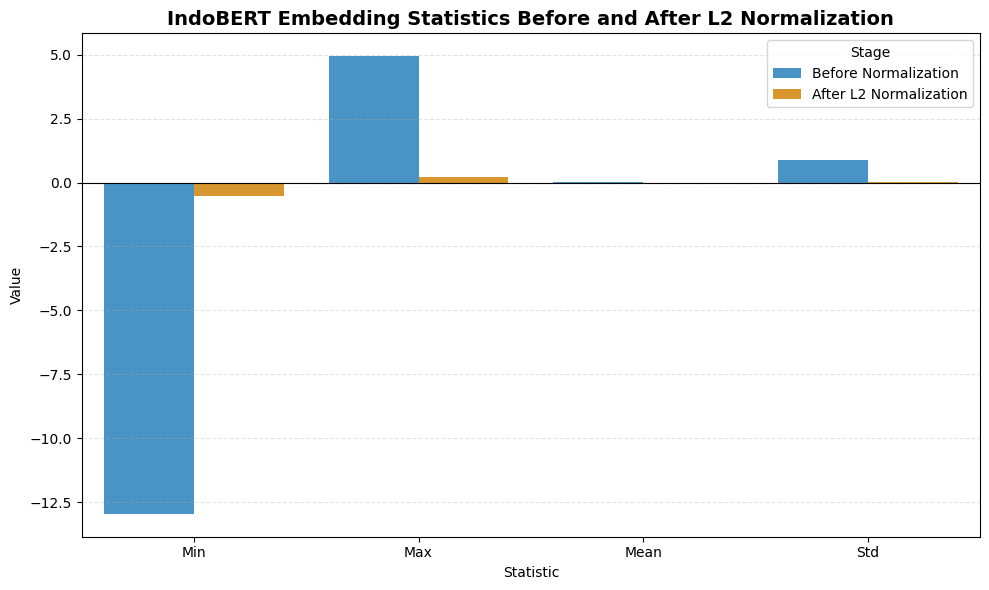

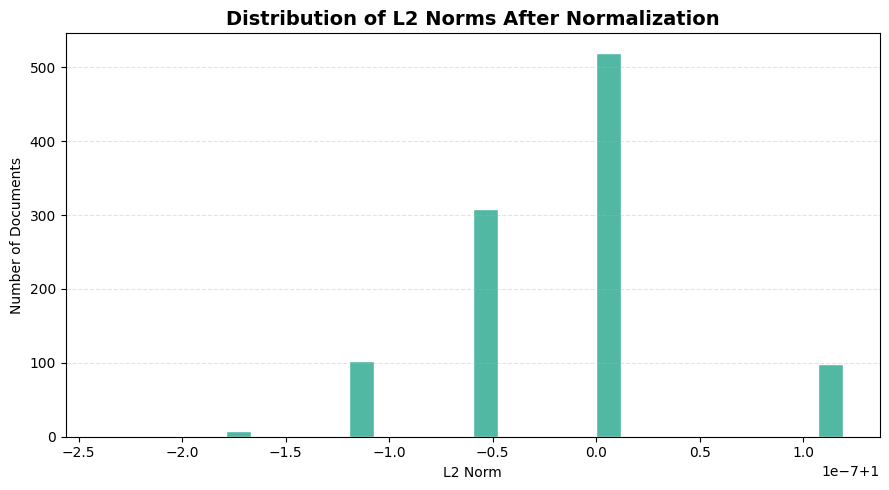

L2 Norm Summary:
Min : 1.0000
Max : 1.0000
Mean: 1.0000


In [22]:
# Statistik sebelum normalisasi
if 'indobert_embeddings' in globals():
    before_matrix = indobert_embeddings
else:
    before_matrix = embedding_matrix

before_stats = {
    'Min': before_matrix.min(),
    'Max': before_matrix.max(),
    'Mean': before_matrix.mean(),
    'Std': before_matrix.std()
}

after_stats = {
    'Min': embedding_matrix.min(),
    'Max': embedding_matrix.max(),
    'Mean': embedding_matrix.mean(),
    'Std': embedding_matrix.std()
}

stats_df = pd.DataFrame({
    'Before Normalization': before_stats,
    'After L2 Normalization': after_stats
})

display(stats_df)

stats_plot_df = stats_df.reset_index().melt(
    id_vars='index',
    var_name='Stage',
    value_name='Value'
).rename(columns={'index': 'Statistic'})

plt.figure(figsize=(10, 6))
sns.barplot(
    data=stats_plot_df,
    x='Statistic',
    y='Value',
    hue='Stage',
    palette=['#3498db', '#f39c12']
)

plt.title('IndoBERT Embedding Statistics Before and After L2 Normalization', fontsize=14, fontweight='bold')
plt.xlabel('Statistic')
plt.ylabel('Value')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

# Cek L2 norm
l2_norms = np.linalg.norm(embedding_matrix, axis=1)

plt.figure(figsize=(9, 5))
sns.histplot(l2_norms, bins=30, color='#16a085', edgecolor='white')

plt.title('Distribution of L2 Norms After Normalization', fontsize=14, fontweight='bold')
plt.xlabel('L2 Norm')
plt.ylabel('Number of Documents')
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

print("L2 Norm Summary:")
print(f"Min : {l2_norms.min():.4f}")
print(f"Max : {l2_norms.max():.4f}")
print(f"Mean: {l2_norms.mean():.4f}")



🔄 Reducing IndoBERT embeddings for visualization (PCA)...
  - Explained variance ratio: 0.2423
  - PC1: 0.1502
  - PC2: 0.0921


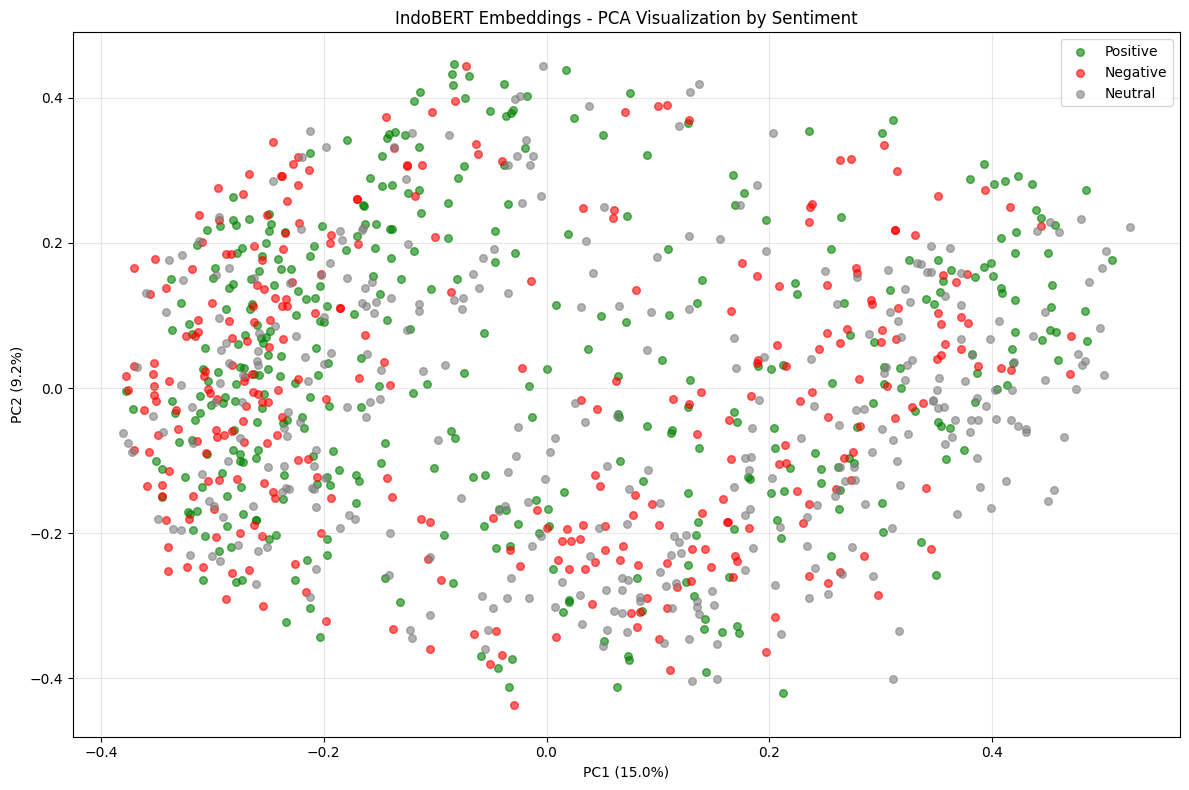

In [24]:
# Visualize IndoBERT embedding statistics with PCA
from sklearn.decomposition import PCA

print("\n🔄 Reducing IndoBERT embeddings for visualization (PCA)...")
print("="*60)

# Pastikan jumlah embedding sama dengan jumlah data BERT
assert indobert_embeddings.shape[0] == len(df_bert), (
    f"Jumlah embedding ({indobert_embeddings.shape[0]}) tidak sama "
    f"dengan jumlah data BERT ({len(df_bert)})"
)

# PCA to 2D
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(indobert_embeddings)

print(f"  - Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")
print(f"  - PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  - PC2: {pca.explained_variance_ratio_[1]:.4f}")

# Plot with sentiment colors
sentiment_colors = {
    'Positive': 'green',
    'Negative': 'red',
    'Neutral': 'gray'
}

sentiments = df_bert['Sentiment'].astype(str)

plt.figure(figsize=(12, 8))

for sentiment in ['Positive', 'Negative', 'Neutral']:
    mask = sentiments == sentiment

    plt.scatter(
        embeddings_2d[mask.values, 0],
        embeddings_2d[mask.values, 1],
        label=sentiment,
        alpha=0.6,
        s=30,
        color=sentiment_colors[sentiment]
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("IndoBERT Embeddings - PCA Visualization by Sentiment")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Hasil PCA menunjukkan bahwa dua komponen utama pertama menjelaskan 24.23% variasi total data, dengan kontribusi PC1 sebesar 15.0% dan PC2 sebesar 9.2%. Ini menunjukkan bahwa visualisasi 2D hanya merepresentasikan sebagian informasi dari embedding IndoBERT berdimensi tinggi.

## Comparison of Feature Extraction Methods

In [25]:
# Create comparison summary# TF-IDF & BoW menggunakan data/processed/dataset_lpdp_preprocessed.csv (text_clean)# IndoBERT menggunakan data/processed/dataset_lpdp_preprocessed_bert.csv (text_bert)tfidf_data = tfidf_matrix if 'tfidf_matrix' in globals() else X_tfidfbow_data = bow_matrix if 'bow_matrix' in globals() else X_bowcomparison_df = pd.DataFrame({    'Method': [        'TF-IDF (n-gram)',        'Bag of Words',        'IndoBERT'    ],    'Input Dataset': [        'data/processed/dataset_lpdp_preprocessed.csv',        'data/processed/dataset_lpdp_preprocessed.csv',        'data/processed/dataset_lpdp_preprocessed_bert.csv'    ],    'Text Column': [        'text_clean',        'text_clean',        'text_bert'    ],    'Feature Type': [        'Sparse (n-gram)',        'Sparse (terms)',        'Dense (embeddings)'    ],    'Dimensionality': [        tfidf_data.shape[1],        bow_data.shape[1],        indobert_embeddings.shape[1]    ],    'Data Type': [        'Sparse Matrix',        'Sparse Matrix',        'Dense Array'    ],    'Documents': [        tfidf_data.shape[0],        bow_data.shape[0],        indobert_embeddings.shape[0]    ],    'Memory (approx)': [        f"{(tfidf_data.data.nbytes / 1024**2):.2f} MB",        f"{(bow_data.data.nbytes / 1024**2):.2f} MB",        f"{(indobert_embeddings.nbytes / 1024**2):.2f} MB"    ],    'Sparsity': [        f"{(1 - tfidf_data.nnz / (tfidf_data.shape[0] * tfidf_data.shape[1]))*100:.1f}%",        f"{(1 - bow_data.nnz / (bow_data.shape[0] * bow_data.shape[1]))*100:.1f}%",        "0% (Dense)"    ],    'Contextual': [        'No',        'No',        'Yes (transformer)'    ],    'Interpretability': [        'High',        'High',        'Low'    ]})print("\n📊 Feature Extraction Methods Comparison")print("="*120)print(comparison_df.to_string(index=False))print("="*120)



📊 Feature Extraction Methods Comparison
         Method                      Input Dataset Text Column       Feature Type  Dimensionality     Data Type  Documents Memory (approx)   Sparsity        Contextual Interpretability
TF-IDF (n-gram)      dataset_lpdp_preprocessed.csv  text_clean    Sparse (n-gram)            5000 Sparse Matrix       1038         1.67 MB      95.8%                No             High
   Bag of Words      dataset_lpdp_preprocessed.csv  text_clean     Sparse (terms)            5000 Sparse Matrix       1038         1.52 MB      96.2%                No             High
       IndoBERT dataset_lpdp_preprocessed_bert.csv   text_bert Dense (embeddings)             768   Dense Array       1038         3.04 MB 0% (Dense) Yes (transformer)              Low


TF-IDF
Seimbang untuk klasifikasi teks.
Masih mudah dijelaskan, dan lebih pintar dari BoW karena memberi bobot pentingnya kata.

BoW
Paling sederhana dan hemat memori.
Tapi hanya menghitung frekuensi kata, jadi biasanya kurang kuat dibanding TF-IDF.

IndoBERT
Paling kaya konteks.
Bisa menangkap makna kalimat lebih baik, tapi lebih sulit dijelaskan dan lebih berat memorinya.

In [26]:
print("💾 Saving extracted features...")print("="*60)# Create features directory if not existsfeatures_dir = Path('features_extraction')features_dir.mkdir(exist_ok=True)# Ambil nama variabel yang sesuaitfidf_data = tfidf_matrix if 'tfidf_matrix' in globals() else X_tfidftfidf_features = feature_names_tfidf if 'feature_names_tfidf' in globals() else feature_namesbow_data = bow_matrix if 'bow_matrix' in globals() else X_bowbow_features = feature_names_bow# Save TF-IDFtfidf_path = features_dir / 'feature_tfidf_ngram.pkl'with open(tfidf_path, 'wb') as f:    pickle.dump({        'matrix': tfidf_data,        'vectorizer': tfidf_vectorizer,        'feature_names': tfidf_features,        'dataset_path': 'data/processed/dataset_lpdp_preprocessed.csv',        'text_column': 'text_clean'    }, f)print(f"✅ TF-IDF saved: {tfidf_path}")# Save Bag of Wordsbow_path = features_dir / 'feature_bow.pkl'with open(bow_path, 'wb') as f:    pickle.dump({        'matrix': bow_data,        'vectorizer': bow_vectorizer,        'feature_names': bow_features,        'dataset_path': 'data/processed/dataset_lpdp_preprocessed.csv',        'text_column': 'text_clean'    }, f)print(f"✅ Bag of Words saved: {bow_path}")# Save IndoBERT embeddingsindobert_path = features_dir / 'feature_indobert_embeddings.pkl'with open(indobert_path, 'wb') as f:    pickle.dump({        'embeddings': indobert_embeddings,        'model_name': model_name,        'dataset_path': 'data/processed/dataset_lpdp_preprocessed_bert.csv',        'text_column': 'text_bert',        'embedding_dim': indobert_embeddings.shape[1]    }, f)print(f"✅ IndoBERT embeddings saved: {indobert_path}")# Save dataset with feature metadata# Metadata ini menjadi mapping antara artikel/label dengan baris fitur.df_with_features = df.copy()df_with_features['tfidf_feature_idx'] = range(len(df_with_features))df_with_features['bow_feature_idx'] = range(len(df_with_features))df_with_features['sentiment_label'] = df_with_features['Sentiment']# Tambahkan index IndoBERT jika urutan doc_id df dan df_bert samaif len(df_with_features) == len(df_bert) and df_with_features['doc_id'].reset_index(drop=True).equals(df_bert['doc_id'].reset_index(drop=True)):    df_with_features['indobert_feature_idx'] = range(len(df_bert))    df_with_features['indobert_text_column'] = 'text_bert'    df_with_features['indobert_dataset'] = 'data/processed/dataset_lpdp_preprocessed_bert.csv'else:    raise ValueError(        "Urutan/jumlah doc_id antara df dan df_bert tidak sama. "        "Metadata IndoBERT tidak bisa digabung aman."    )dataset_path = features_dir / 'dataset_with_features_metadata.csv'df_with_features.to_csv(dataset_path, index=False)print(f"✅ Dataset with metadata saved: {dataset_path}")print("\n📌 Saved files:")print(f"  - TF-IDF   : {tfidf_path}")print(f"  - BoW      : {bow_path}")print(f"  - IndoBERT : {indobert_path}")print(f"  - Metadata : {dataset_path}")


💾 Saving extracted features...
✅ TF-IDF saved: features_extraction\feature_tfidf_ngram.pkl
✅ Bag of Words saved: features_extraction\feature_bow.pkl
✅ IndoBERT embeddings saved: features_extraction\feature_indobert_embeddings.pkl
✅ Dataset with metadata saved: features_extraction\dataset_with_features_metadata.csv

📌 Saved files:
  - TF-IDF   : features_extraction\feature_tfidf_ngram.pkl
  - BoW      : features_extraction\feature_bow.pkl
  - IndoBERT : features_extraction\feature_indobert_embeddings.pkl
  - Metadata : features_extraction\dataset_with_features_metadata.csv
